# Logistic Regression & Confusion Matrix 



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/shailesh/Desktop/vedam_Sem3_ml/Data/Titanic-Dataset.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


---
## 1. Where we are

> **Flow:** Last class the target was a number. Today it is back to a label.

| | target | model |
|---|---|---|
| Lecture 1 | `origin` — a label | KNN |
| Lecture 2 | `mpg` — a number | Linear Regression |
| Today | `Survived` — a label | Logistic Regression |

---
## 2. What is logistic regression?

> **Flow:** A straight line does not stop at 0 and 1. The sigmoid makes it.

`Survived` is only ever 0 or 1. A straight line keeps going in both directions, so it will
predict 1.4 for one passenger and −0.3 for another. Neither is a possible answer.

Logistic regression fixes this in one step. It takes whatever number the line produces and
passes it through the **sigmoid**, which squashes any number into the range 0 to 1:

So the output is always a probability.

- above 0.5 → predict **1**
- below 0.5 → predict **0**

That is the whole idea. Everything else is the same as linear regression.

**What it assumes**

| Assumption | Titanic |
|---|---|
| The target is a label, not a number | Yes |
| Rows are independent of each other | Mostly — families travelled together |
| Features are not copies of each other | `Fare` and `Pclass` overlap |
| No extreme outliers | `Fare` reaches 512 |

None of these has to be perfect. They tell you where the model will struggle, not whether
you are allowed to run it.

---
## 3. Look at the data

> **Flow:** Before modelling, see what is actually in there.

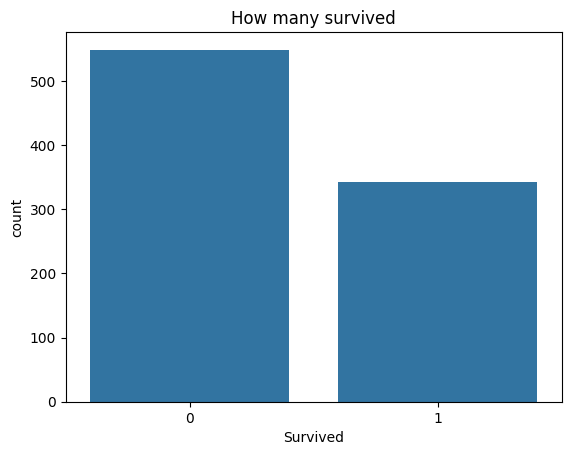

In [3]:
sns.countplot(data=df, x='Survived')
plt.title('How many survived')
plt.show()

Far more died than survived. **Remember this** — it comes back in section 7.

---
## 4. Clean and split

> **Flow:** Same steps as always.

In [4]:
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId', 'Embarked'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df.shape, "|", df.isna().sum().sum(), "missing")
df.head()

(891, 7) | 0 missing


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


`Sex` has exactly two values, so mapping it to 0 and 1 invents no order.
`Embarked` is dropped to keep today's code short.

In [5]:
X = df.drop(columns='Survived')
y = df['Survived']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(712, 6) (179, 6)


---
## 5. Train the model

> **Flow:** Same two lines. Only the model changed.

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred[:15])

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 1]


/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8044692737430168


**0.8045.** Hold on to that number.

---
> ### Starting here today
>
> Sections 1 to 5 were covered last class. **Restart the kernel and Run All up to
> section 5**, so that `model`, `X_test`, `y_test` and `y_pred` exist again.
>
> Today: sections 6 to 10.

---
## 6. How sure is the model?

> **Flow:** It does not just answer. It gives a probability.

In [17]:
probs = model.predict_proba(X_test)
pd.DataFrame(probs[:8].round(3), columns=['P(died)', 'P(survived)'])

/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,P(died),P(survived)
0,0.922,0.078
1,0.945,0.055
2,0.872,0.128
3,0.959,0.041
4,0.445,0.555
5,0.520,0.480
6,0.227,0.773
7,0.654,0.346


`predict()` simply takes whichever side of 0.5 the probability falls on.

---
## 7. Confusion matrix

> **Flow:** One accuracy number hides what kind of mistakes the model makes.

Our model scored 0.8045. Before deciding that is good, compare it against a model that
learns nothing at all — one that always says "died".

In [9]:
print("always predict died:", (y_test == 0).mean())
print("our model:          ", accuracy_score(y_test, y_pred))

always predict died: 0.6145251396648045
our model:           0.8044692737430168


**0.6145 without learning anything.**

That is the problem with accuracy on this dataset: most passengers died, so guessing
"died" every time already gets you 61%. Our 0.8045 is real, but it is not as impressive
as it first looked.

Accuracy tells us *how many* were wrong. It never tells us *which* were wrong.

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[95 15]
 [20 49]]


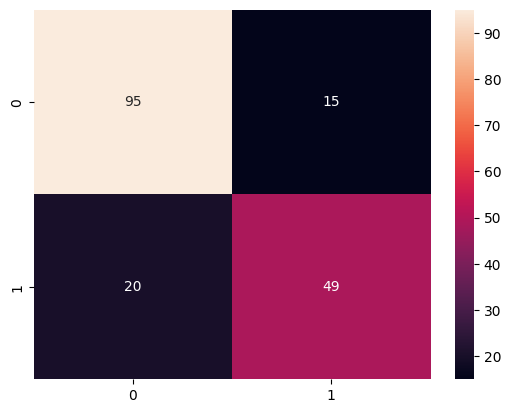

In [18]:
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

| | predicted: died | predicted: survived |
|---|---|---|
| **actual: died** | 95 | 15 |
| **actual: survived** | **20** | 49 |

Read it row by row:

- **95** really died, and we said died — correct
- **49** really survived, and we said survived — correct
- **15** really died, but we said survived — a false alarm
- **20 really survived, but we said died** — a miss

That bottom-left box is the one to look at. Twenty people lived and the model wrote them
off. An accuracy of 0.80 never showed you that.

**The four boxes have names.** Taking "survived" as the class we care about:

| | predicted: no | predicted: yes |
|---|---|---|
| **actual: no** | True Negative (95) | False Positive (15) |
| **actual: yes** | False Negative (20) | True Positive (49) |

The second word is what the model said. The first word is whether it was right.

- **False Positive** — model said yes, reality said no. A false alarm.
- **False Negative** — model said no, reality said yes. A miss.

### Practice 7

**Q1.** A cancer screening test has 2 in the False Positive box and 40 in the False
Negative box. Which mistake is more dangerous here, and why?

**Q2.** A model that always predicts "died" is run on our test set.
What would its confusion matrix look like?

**Q3.** A spam filter puts a real email from your manager into the spam folder.
Which box is that, taking "spam" as the class we care about?

<details><summary>Answers</summary>

1. The 40 False Negatives — patients who have cancer but are told they do not. A false
   alarm leads to another test; a miss leads to an untreated illness.
2. The whole right column would be 0. All 110 actual deaths in the top-left, all 69 actual
   survivors in the bottom-left.
3. False Positive — the model said spam, reality said not spam.
</details>

---
## 8. Precision, recall, F1

> **Flow:** Three numbers built from those four boxes.

Accuracy squashes all four boxes into one number. These three keep them apart.

| | formula | plain words |
|---|---|---|
| Precision | TP / (TP + FP) | of everyone we *called* positive, how many really were |
| Recall | TP / (TP + FN) | of everyone who really *was* positive, how many did we find |
| F1 | balance of the two | one number when you need a single score |

For our "survived" class: TP = 49, FP = 15, FN = 20.

In [12]:
print("precision:", 49 / (49 + 15))
print("recall:   ", 49 / (49 + 20))

precision: 0.765625
recall:    0.7101449275362319


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



For the "survived" class:

| | value | in words |
|---|---|---|
| Precision | 0.766 | of everyone we called a survivor, 77% really were |
| Recall | 0.710 | of everyone who really survived, we found 71% |
| F1 | 0.737 | the balance of the two |

**Precision is about false alarms. Recall is about misses.**

Which matters depends on the job:

- A cancer screening test needs high **recall** — missing a sick patient is unacceptable.
- A spam filter needs high **precision** — losing a real email is worse than seeing one spam.

`support` is just how many test rows belonged to each class: 110 died, 69 survived.

---
## 9. Hands-on — your penguins model

> **Flow:** You already built the model. Now measure it properly.

**Open your assignment notebook** (`Assignment_Logistic_Regression_penguins.ipynb`) and
run it up to the accuracy cell. You already have `model`, `X_test`, `y_test` and your
predictions there.

Everything below goes into that notebook, not this one.

**Step 1.** Build the confusion matrix and draw it as a heatmap

**Step 2.** Print the classification report.

Which is higher for the `Male` class — precision or recall? What does that mean in
plain words?

**Step 3.** Try thresholds 0.3 and 0.7 on your probabilities, the way we did in 8b.
Print the confusion matrix for each.

What happens to the number of misses as the threshold goes up?

**Q.** On Titanic, accuracy was misleading because most passengers died, so the baseline
was already 0.6145. In your penguins data the two classes are close to equal in size.
Is accuracy misleading here too? Two lines.

*Your answer:*

---
## 10. Quiz

**Q1.** Why can we not use linear regression to predict `Survived`?

<details><summary>Answer</summary>
A straight line does not stop at 0 and 1, so it predicts values like 1.4 and −0.3 that
are not possible answers.
</details>

**Q2.** What does the sigmoid do?

<details><summary>Answer</summary>
It squashes any number into the range 0 to 1, so the output can be read as a probability.
</details>

**Q3.** A model reports 0.80 accuracy, and always predicting the most common class gives
0.61. What does that tell you?

<details><summary>Answer</summary>
The model learned something real, but less than 0.80 suggests on its own.
Always compare against the baseline.
</details>

**Q4.** What sits in the False Negative box?

<details><summary>Answer</summary>
Rows that really were positive but were predicted negative — the misses.
</details>

**Q5.** A spam filter should have high precision or high recall? Why?

<details><summary>Answer</summary>
High precision. A real email pushed into the spam folder is worse than one spam message
reaching the inbox.
</details>

